# Reliability Lifetime Prediction from Degradation Time-Series Data

This notebook demonstrates an end-to-end reliability modeling workflow using fully synthetic degradation data.

The analysis includes:

- degradation time-series preprocessing
- stretched-exponential model fitting
- sample-level lifetime estimation
- model evaluation using R²
- population-level variability analysis
- aggregate lifetime modeling
- visualization of lifetime distributions

**Note:** All data and parameters in this project are synthetic and were independently created for educational and portfolio purposes.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from lifetime_model import fit_lifetime_model
from analysis import analyze_dataset, summarize_results

## 1. Load Synthetic Degradation Data

The dataset contains 100 synthetic samples measured over time.

Each sample represents a degradation trajectory with slightly different model parameters and random measurement noise.

In [2]:
data_path = project_root / "data" / "synthetic_degradation.csv"

df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (51, 101)


,Time,Sample_001,Sample_002,Sample_003,Sample_004,Sample_005,Sample_006,Sample_007,Sample_008,Sample_009,...,Sample_091,Sample_092,Sample_093,Sample_094,Sample_095,Sample_096,Sample_097,Sample_098,Sample_099,Sample_100
0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,20.0,0.999077,0.998110,0.997000,1.000168,0.999098,0.998168,0.998119,0.998454,0.999754,...,0.999011,0.997870,0.997207,0.999446,0.998575,0.997013,0.998577,0.997246,0.997054,0.998024
2,40.0,0.995849,0.998594,0.997822,0.996967,0.997776,0.997054,0.998270,0.998704,0.996362,...,0.997525,0.997002,0.996541,0.997359,0.997477,0.996462,0.996013,0.997896,0.996329,0.998151
3,60.0,0.995617,0.995935,0.996913,0.997604,0.997630,0.995585,0.997164,0.995699,0.997029,...,0.997661,0.997360,0.996262,0.995675,0.996475,0.996551,0.996145,0.998425,0.995641,0.997467
4,80.0,0.996099,0.996722,0.995583,0.995602,0.995742,0.995624,0.997343,0.993388,0.995217,...,0.995865,0.994049,0.994715,0.994606,0.995041,0.995162,0.995708,0.995974,0.995134,0.996474


## 2. Explore Degradation Trajectories

Before fitting a model, we first inspect several sample trajectories to understand the overall degradation behavior and sample-to-sample variation.

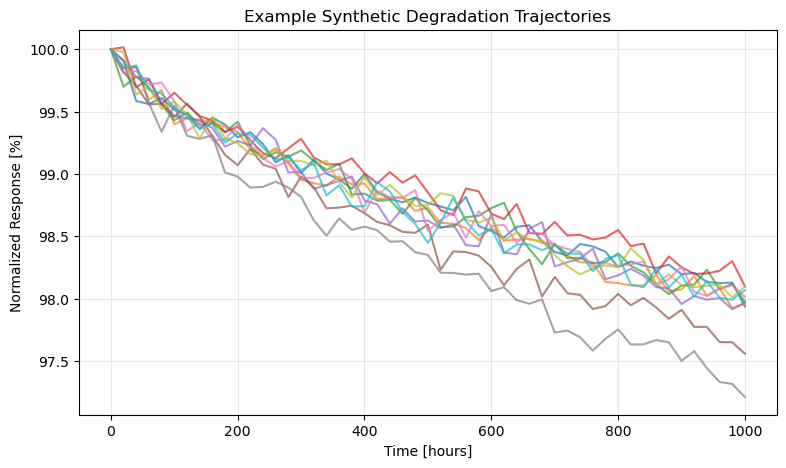

In [3]:
plt.figure(figsize=(9, 5))

for sample in df.columns[1:11]:
    plt.plot(
        df["Time"],
        df[sample] * 100,
        alpha=0.7
    )

plt.xlabel("Time [hours]")
plt.ylabel("Normalized Response [%]")
plt.title("Example Synthetic Degradation Trajectories")
plt.grid(alpha=0.3)
plt.show()

## 3. Fit a Stretched-Exponential Model

Each sample is modeled using a stretched-exponential degradation function.

The fitted model is then used to estimate T95, defined in this project as the time at which the normalized response reaches 95% of its initial value.

In [4]:
sample_name = "Sample_001"

time = df["Time"].to_numpy()
values = df[sample_name].to_numpy()

result = fit_lifetime_model(time, values)

print(f"Sample: {sample_name}")
print(f"a: {result['a']:.6f}")
print(f"b: {result['b']:.4f}")
print(f"R²: {result['r2']:.4f}")
print(f"Estimated T95: {result['t95']:.1f} hours")

Sample: Sample_001
a: 0.000260
b: 0.6247
R²: 0.9858
Estimated T95: 4712.6 hours


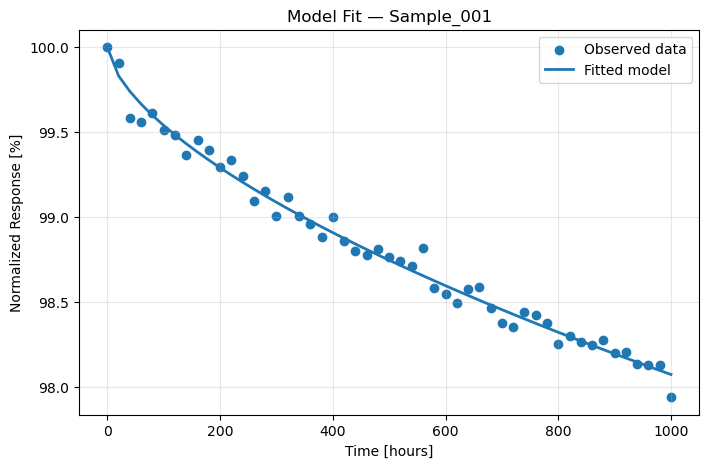

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    time,
    result["normalized_values"] * 100,
    label="Observed data"
)

plt.plot(
    time,
    result["predicted_values"] * 100,
    linewidth=2,
    label="Fitted model"
)

plt.xlabel("Time [hours]")
plt.ylabel("Normalized Response [%]")
plt.title(f"Model Fit — {sample_name}")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 4. Estimate Lifetime Across All Samples

The same fitting procedure is applied independently to all 100 samples.

This allows us to evaluate both model performance and sample-to-sample lifetime variability.

In [7]:
results_df = analyze_dataset(data_path)

results_df.head()

,sample,a,b,r2,t95
0,Sample_001,0.000260,0.624721,0.985789,4712.591510
1,Sample_002,0.000237,0.647578,0.988144,4040.298760
2,Sample_003,0.000243,0.638678,0.976485,4350.604862
3,Sample_004,0.000196,0.657529,0.976904,4772.482736
4,Sample_005,0.000249,0.642255,0.976181,4014.835371


In [8]:
summary, outliers = summarize_results(results_df)

summary

{'mean_t95': np.float64(3816.841971718324),
 'std_t95': 1161.7210210163923,
 'cv_t95_percent': np.float64(30.4367073518999),
 'mean_r2': np.float64(0.9819831355421751),
 'n_samples': 100,
 'n_valid_t95': 100,
 'n_outliers': 2}

### Summary

The models achieved strong overall goodness of fit while showing meaningful variation in estimated lifetime across samples.

The variation is intentional in the synthetic dataset and demonstrates why population-level reliability analysis should consider both the central estimate and unit-to-unit variability.

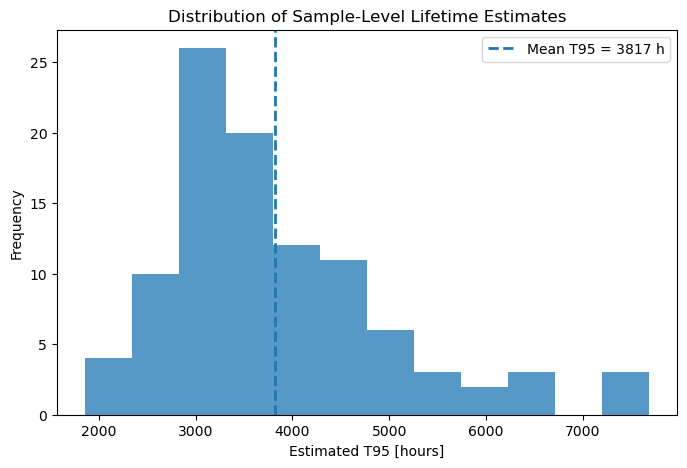

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(
    results_df["t95"],
    bins=12,
    alpha=0.75
)

plt.axvline(
    results_df["t95"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean T95 = {results_df['t95'].mean():.0f} h"
)

plt.xlabel("Estimated T95 [hours]")
plt.ylabel("Frequency")
plt.title("Distribution of Sample-Level Lifetime Estimates")
plt.legend()
plt.show()

## Key Takeaways

This case study demonstrates how degradation time-series data can be transformed into interpretable lifetime estimates using nonlinear modeling.

Key observations include:

- The stretched-exponential model achieved strong fit across the synthetic sample population.
- Lifetime predictions varied meaningfully across samples despite similar overall degradation patterns.
- Evaluating both model fit and population variability is important when interpreting long-horizon lifetime predictions.
- Potential outliers can be identified for additional investigation rather than being treated as ordinary observations.

### Next Steps

Future extensions could include:

- uncertainty intervals for lifetime predictions
- residual-based model diagnostics
- partial-window prediction experiments
- comparison with alternative degradation models
- more robust outlier detection
- interactive model exploration using Streamlit